In [1]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict

In [2]:
class Simple(TypedDict):
    num1: float
    num2: float 
    addition_result : float
    final: float

In [3]:
graph = StateGraph(Simple)

In [4]:
def calculate_sum(state: Simple) -> Simple  :
    num1 = state['num1']
    num2 = state['num2']
    addition_result = num1 + num2
    state['addition_result'] = addition_result
    return state
def final_result(state: Simple) -> Simple:
    addition_res = state['addition_result']
    final = addition_res * 2
    state['final'] = final
    return state

In [5]:
graph.add_node("calculate_sum", calculate_sum)
graph.add_node("final_result", final_result)
graph.add_edge(START, "calculate_sum")
graph.add_edge("calculate_sum", "final_result")
graph.add_edge("final_result", END)

In [6]:
workflow = graph.compile()

In [7]:
initial_state = {'num1': 10.0, 'num2': 20.0}
output_state = workflow.invoke(initial_state)
print(output_state)

{'num1': 10.0, 'num2': 20.0, 'addition_result': 30.0, 'final': 60.0}


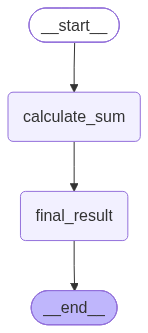

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())